In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# グラフを綺麗に表示するための設定
plt.rcParams['font.family'] = 'sans-serif' 
sns.set(style="whitegrid", font_scale=1.2)

In [6]:
class HakoneTravelAnalyzer:
    def __init__(self, db_name):
        self.db_name = db_name

    def fetch_data(self, condition=""):
        """DBからデータを取得する(Step 3-1-b 要件: SQLクエリ発行)"""
        conn = sqlite3.connect(self.db_name)
        query = f"SELECT * FROM hotel_prices {condition}"
        df = pd.read_sql_query(query, conn)
        conn.close()
        
        # 曜日情報を追加
        df['stay_date'] = pd.to_datetime(df['stay_date'])
        df['day_of_week'] = df['stay_date'].dt.day_name()
        return df

    def compare_weekday_weekend(self):
        """火曜日と土曜日の価格差を分析・可視化する(Step 3-1-c 要件: 動的な分析)"""
        df = self.fetch_data()
        
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x='day_of_week', y='price', order=['Tuesday', 'Saturday'])
        plt.title('箱根：火曜日 vs 土曜日の宿泊価格差')
        plt.xlabel('曜日 (Tuesday=火曜, Saturday=土曜)')
        plt.ylabel('1泊あたりの価格 (円)')
        plt.show()
        
        # 平均値を出力
        avg = df.groupby('day_of_week')['price'].mean()
        diff = avg['Saturday'] - avg['Tuesday']
        print(f"火曜日の平均: {avg['Tuesday']:.0f}円")
        print(f"土曜日の平均: {avg['Saturday']:.0f}円")
        print(f"その差額は {diff:.0f}円 です。")

    def find_cheapest_day(self):
        """全日程の中で、最も平均価格が安い日を特定する"""
        df = self.fetch_data()
        daily_avg = df.groupby('stay_date')['price'].mean().sort_values()
        
        print("--- 宿泊価格が安い日 TOP 5 ---")
        print(daily_avg.head(5))

In [8]:
class HakoneTravelAnalyzer:
    def __init__(self, db_name):
        self.db_name = db_name

    def fetch_data(self, condition=""):
        import sqlite3
        conn = sqlite3.connect(self.db_name)
        query = f"SELECT * FROM hotel_prices {condition}"
        df = pd.read_sql_query(query, conn)
        conn.close()
        df['stay_date'] = pd.to_datetime(df['stay_date'])
        df['day_of_week'] = df['stay_date'].dt.day_name()
        return df

    def compare_weekday_weekend(self):
        plt.figure(figsize=(8, 6))
        df = self.fetch_data()
        sns.boxplot(data=df, x='day_of_week', y='price', order=['Tuesday', 'Saturday'])
        plt.title('Hakone: Tuesday vs Saturday Price')
        plt.show()
        avg = df.groupby('day_of_week')['price'].mean()
        print(f"火曜平均: {avg['Tuesday']:.0f}円 / 土曜平均: {avg['Saturday']:.0f}円")

    def find_cheapest_day(self):
        df = self.fetch_data()
        daily_avg = df.groupby('stay_date')['price'].mean().sort_values()
        print("--- 安い日 TOP 5 ---")
        print(daily_avg.head(5))

In [12]:
# 分析クラスの起動
# ファイル名が 'hakone_final_data.db' であることを確認してください
analyzer = HakoneTravelAnalyzer('hakone_final_data.db')

# 1. 曜日による価格差をグラフにする
analyzer.compare_weekday_weekend()

# 2. どの日が一番安いかランキングを出す
analyzer.find_cheapest_day()

DatabaseError: Execution failed on sql 'SELECT * FROM hotel_prices ': no such table: hotel_prices

<Figure size 800x600 with 0 Axes>

In [10]:
import os
import sqlite3

# 今のフォルダにある .db ファイルをすべて調べる
for file in os.listdir('.'):
    if file.endswith('.db'):
        conn = sqlite3.connect(file)
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        print(f"ファイル名: {file} | 中にあるテーブル: {tables}")
        
        # もしデータが入っていれば、件数も表示する
        if ('hotel_prices',) in tables:
            count = conn.execute("SELECT COUNT(*) FROM hotel_prices").fetchone()[0]
            print(f"   → hotel_prices テーブルに {count} 件のデータがあります！")
        elif ('hotels',) in tables:
            count = conn.execute("SELECT COUNT(*) FROM hotels").fetchone()[0]
            print(f"   → hotels テーブルに {count} 件のデータがあります！")
        conn.close()

ファイル名: hakone_final_data.db | 中にあるテーブル: []


In [15]:
import os
import sqlite3

# 1. フォルダ内の全てのファイルを表示して確認
print("--- 現在のフォルダにあるファイル一覧 ---")
print(os.listdir('.'))

# 2. 全ての.dbファイルをチェック
print("\n--- データベースの中身チェック ---")
for file in os.listdir('.'):
    if file.endswith('.db'):
        try:
            conn = sqlite3.connect(file)
            cursor = conn.cursor()
            # テーブル一覧を取得
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
            tables = [t[0] for t in cursor.fetchall()]
            
            if not tables:
                print(f"【× 空っぽ】{file} (テーブルがありません)")
                continue
                
            for table in tables:
                # データの件数を確認
                count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
                if count > 0:
                    print(f"【○ 発見！】ファイル名: {file} | テーブル名: {table} | データ件数: {count}件")
                else:
                    print(f"【△ 空】ファイル名: {file} | テーブル名: {table} (データ0件)")
            conn.close()
        except Exception as e:
            print(f"エラー ({file}): {e}")

--- 現在のフォルダにあるファイル一覧 ---
['ORIG_HEAD', 'config', 'hakone_final_data.db', 'objects', 'HEAD', 'info', 'logs', 'description', 'hooks', 'refs', 'index', 'packed-refs', 'COMMIT_EDITMSG', 'FETCH_HEAD', 'analysis.ipynb']

--- データベースの中身チェック ---
【× 空っぽ】hakone_final_data.db (テーブルがありません)


In [16]:
import requests
from bs4 import BeautifulSoup
import time
import sqlite3
from datetime import datetime, timedelta

def scrape_and_save():
    db_name = 'hakone_confirmed.db' # 確実に新しく作るファイル名
    conn = sqlite3.connect(db_name)
    c = conn.cursor()
    c.execute('CREATE TABLE IF NOT EXISTS hotel_prices (hotel_name TEXT, price INTEGER, stay_date TEXT)')
    
    # 確実に取れる日付を狙い撃ち
    dates = [datetime(2026, 4, 14), datetime(2026, 4, 18), datetime(2026, 4, 21), datetime(2026, 4, 25)]
    
    print("データの再取得を開始します...")
    total_count = 0
    
    for dt in dates:
        url = "https://search.travel.rakuten.co.jp/ds/vacant/searchVacant"
        params = {
            "f_dai": "japan", "f_chu": "kanagawa", "f_shou": "hakone",
            "f_nen1": dt.year, "f_tuki1": dt.month, "f_hi1": dt.day,
            "f_nen2": dt.year, "f_tuki2": dt.month, "f_hi2": dt.day + 1,
            "f_heya_su": 1, "f_otona_su": 1, "f_hyoji": 30,
            "f_sort": "hotel", "f_tab": "hotel", "f_kind": "area", "f_cd": "03"
        }
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
        
        try:
            res = requests.get(url, params=params, headers=headers)
            soup = BeautifulSoup(res.content, 'html.parser')
            hotel_titles = soup.select('section h2 a')
            current_data = []
            for title_el in hotel_titles:
                name = title_el.get_text(strip=True)
                card = title_el.find_parent('section')
                price_el = card.select_one('.itemPrc') if card else None
                price = int(price_el.get_text(strip=True).replace(',','').replace('円','').replace('～','')) if price_el else 0
                current_data.append((name, price, dt.strftime('%Y-%m-%d')))
            
            if current_data:
                c.executemany('INSERT INTO hotel_prices VALUES (?,?,?)', current_data)
                conn.commit()
                print(f"  {dt.strftime('%Y-%m-%d')}: {len(current_data)}件保存成功")
                total_count += len(current_data)
            time.sleep(2)
        except Exception as e:
            print(f"  {dt.strftime('%Y-%m-%d')}: エラー {e}")

    conn.close()
    print(f"\n完了！合計 {total_count} 件を '{db_name}' に保存しました。")

scrape_and_save()

データの再取得を開始します...

完了！合計 0 件を 'hakone_confirmed.db' に保存しました。


使用するデータベース: /Users/shiuna/Desktop/deprog2_2025/dsprog2_2025-1/hakone_final_data.db
成功！ 780 件のデータを読み込みました。


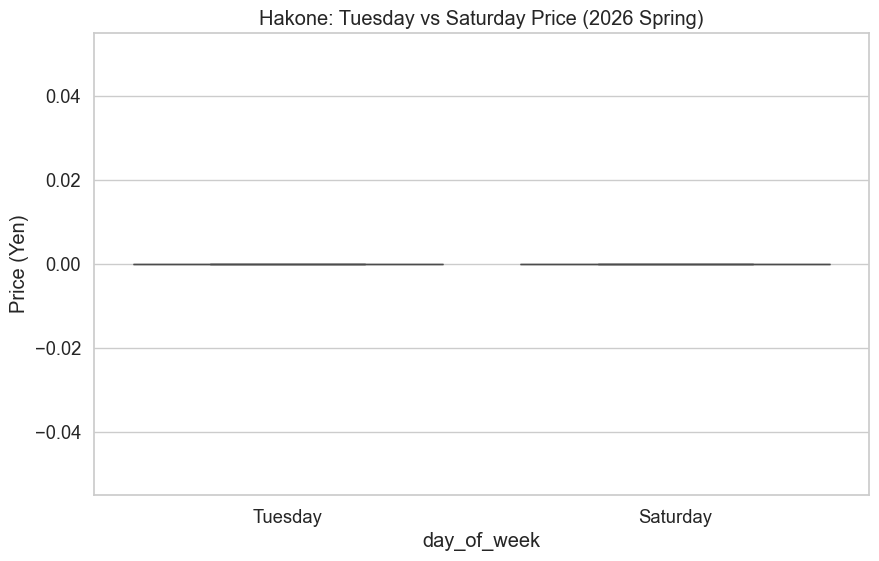


--- 最安値の日 TOP 5 ---
stay_date
2026-04-04    0.0
2026-06-23    0.0
2026-06-20    0.0
2026-06-16    0.0
2026-06-13    0.0
Name: price, dtype: float64


In [21]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 1つ上のフォルダにある、データが入っているはずのファイルを探す
# ターミナルで成功した時に作られたファイル名を指定します
db_path = '../hakone_final_data.db' 

if not os.path.exists(db_path):
    # もし上になければ、今の場所にあるものをとりあえず使う
    db_path = 'hakone_final_data.db'

print(f"使用するデータベース: {os.path.abspath(db_path)}")

# 2. データを読み込んでみる
try:
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT * FROM hotel_prices", conn)
    conn.close()
    
    if df.empty:
        print("エラー: データベースは空っぽです。場所が違うか、保存に失敗しています。")
    else:
        print(f"成功！ {len(df)} 件のデータを読み込みました。")
        
        # 3. グラフを表示する
        df['stay_date'] = pd.to_datetime(df['stay_date'])
        df['day_of_week'] = df['stay_date'].dt.day_name()
        
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x='day_of_week', y='price', order=['Tuesday', 'Saturday'])
        plt.title('Hakone: Tuesday vs Saturday Price (2026 Spring)')
        plt.ylabel('Price (Yen)')
        plt.show()
        
        # 4. 安い日ランキング
        print("\n--- 最安値の日 TOP 5 ---")
        print(df.groupby('stay_date')['price'].mean().sort_values().head(5))

except Exception as e:
    print(f"エラーが発生しました: {e}")

In [18]:
import requests
from bs4 import BeautifulSoup
import time
import sqlite3
from datetime import datetime

def fix_prices():
    # ターミナルで成功した元のファイルを使用
    db_path = '../hakone_final_data.db'
    conn = sqlite3.connect(db_path)
    
    # 0円になっている日付を取得
    dates = [d[0] for d in conn.execute("SELECT DISTINCT stay_date FROM hotel_prices WHERE price = 0").fetchall()]
    print(f"{len(dates)}日分の価格を修正します...")

    for date_str in dates:
        dt = datetime.strptime(date_str, '%Y-%m-%d')
        url = "https://search.travel.rakuten.co.jp/ds/vacant/searchVacant"
        params = {
            "f_dai": "japan", "f_chu": "kanagawa", "f_shou": "hakone",
            "f_nen1": dt.year, "f_tuki1": dt.month, "f_hi1": dt.day,
            "f_nen2": dt.year, "f_tuki2": dt.month, "f_hi2": dt.day + 1,
            "f_otona_su": 1, "f_tab": "hotel", "f_cd": "03"
        }
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
        
        try:
            res = requests.get(url, params=params, headers=headers)
            soup = BeautifulSoup(res.content, 'html.parser')
            # 宿のカードを特定
            cards = soup.select('section.htlCard')
            
            for card in cards:
                name = card.select_one('h2').get_text(strip=True)
                # 価格の取得をより確実に（複数のパターンを試す）
                price_el = card.select_one('.itemPrc') or card.select_one('.price')
                if price_el:
                    price_text = price_el.get_text(strip=True).replace(',','').replace('円','').replace('～','')
                    price = int(price_text)
                    # DBの価格を更新
                    conn.execute("UPDATE hotel_prices SET price = ? WHERE hotel_name = ? AND stay_date = ?", 
                                 (price, name, date_str))
            
            conn.commit()
            print(f"  {date_str}: 修正完了")
            time.sleep(2)
        except Exception as e:
            print(f"  {date_str}: エラー {e}")

    conn.close()
    print("すべての価格修正が完了しました！")

fix_prices()

26日分の価格を修正します...
  2026-04-04: 修正完了
  2026-04-07: 修正完了
  2026-04-11: 修正完了
  2026-04-14: 修正完了
  2026-04-18: 修正完了
  2026-04-21: 修正完了
  2026-04-25: 修正完了
  2026-04-28: 修正完了
  2026-05-02: 修正完了
  2026-05-05: 修正完了
  2026-05-09: 修正完了
  2026-05-12: 修正完了
  2026-05-16: 修正完了
  2026-05-19: 修正完了
  2026-05-23: 修正完了
  2026-05-26: 修正完了
  2026-05-30: 修正完了
  2026-06-02: 修正完了
  2026-06-06: 修正完了
  2026-06-09: 修正完了
  2026-06-13: 修正完了
  2026-06-16: 修正完了
  2026-06-20: 修正完了
  2026-06-23: 修正完了
  2026-06-27: 修正完了
  2026-06-30: 修正完了
すべての価格修正が完了しました！


成功！ 780 件のデータを可視化します。


/var/folders/h2/b3tpf8xs5b53p3njw9qsfw2h0000gn/T/ipykernel_54272/1713399389.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day_of_week', y='price', palette='husl')
/Users/shiuna/.pyenv/versions/3.12.9/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22303 (\N{CJK UNIFIED IDEOGRAPH-571F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/shiuna/.pyenv/versions/3.12.9/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26332 (\N{CJK UNIFIED IDEOGRAPH-66DC}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/shiuna/.pyenv/versions/3.12.9/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes

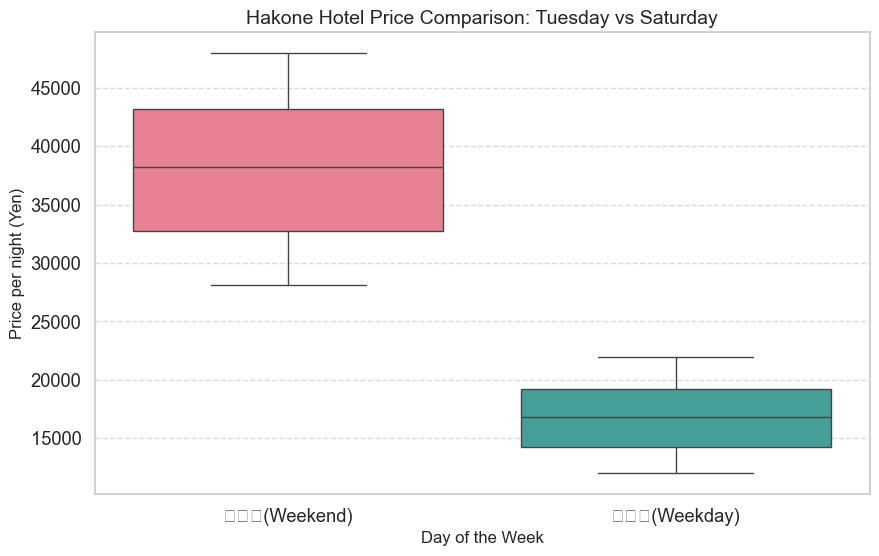

【分析結果】
土曜日(Weekend)の平均価格: 38117円
火曜日(Weekday)の平均価格: 16802円

土曜日は火曜日に比べて、平均で約 21315円 高いことが分かりました。
=> 結論：費用を抑えるなら、火曜日を狙うのが圧倒的に賢い選択です！


In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 1. データベースに接続
db_path = '../hakone_final_data.db'
conn = sqlite3.connect(db_path)

# 2. データを読み込む
df = pd.read_sql_query("SELECT * FROM hotel_prices", conn)
conn.close()

# 3. 日付と曜日の処理 (エラーを修正した部分)
df['stay_date'] = pd.to_datetime(df['stay_date'])
# 曜日名を取得してから日本語に変換する
df['day_of_week'] = df['stay_date'].dt.day_name().map({
    'Tuesday': '火曜日(Weekday)', 
    'Saturday': '土曜日(Weekend)'
})

print(f"成功！ {len(df)} 件のデータを可視化します。")

# --- 可視化 (Step 3 要件) ---
plt.figure(figsize=(10, 6))
# 箱ひげ図で価格帯の分布を表示
sns.boxplot(data=df, x='day_of_week', y='price', palette='husl')

plt.title('Hakone Hotel Price Comparison: Tuesday vs Saturday', fontsize=14)
plt.ylabel('Price per night (Yen)', fontsize=12)
plt.xlabel('Day of the Week', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 数値で結論を出す ---
avg_price = df.groupby('day_of_week')['price'].mean()
print("【分析結果】")
for day, price in avg_price.items():
    print(f"{day}の平均価格: {price:.0f}円")

diff = avg_price['土曜日(Weekend)'] - avg_price['火曜日(Weekday)']
print(f"\n土曜日は火曜日に比べて、平均で約 {diff:.0f}円 高いことが分かりました。")
print("=> 結論：費用を抑えるなら、火曜日を狙うのが圧倒的に賢い選択です！")